In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import mlflow
import mlflow.keras

# Carrega os dados processados
X_train = np.load("../data/processed/v1/X_train.npy")
X_val   = np.load("../data/processed/v1/X_val.npy")
X_test  = np.load("../data/processed/v1/X_test.npy")
y_train = np.load("../data/processed/v1/y_train.npy")
y_val   = np.load("../data/processed/v1/y_val.npy")
y_test  = np.load("../data/processed/v1/y_test.npy")

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val:   {X_val.shape}")
print(f"Shape X_test:  {X_test.shape}")

Shape X_train: (38304, 1, 20)
Shape X_val:   (6758, 1, 20)
Shape X_test:  (6759, 1, 20)


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

def build_lstm_model(input_shape):
    model = Sequential([
        # Camada LSTM 1: 128 unidades
        LSTM(128, return_sequences=True,
             kernel_regularizer=l2(0.0001),
             input_shape=input_shape),
        Dropout(0.3),

        # Camada LSTM 2: 64 unidades
        LSTM(64, return_sequences=False,
             kernel_regularizer=l2(0.0001)),
        Dropout(0.3),

        # Dense 1: 64 unidades
        Dense(64, activation="relu", kernel_regularizer=l2(0.0001)),
        Dropout(0.3),

        # Dense 2: 32 unidades
        Dense(32, activation="relu"),

        # Saida: 1 neuronio + Sigmoid
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Cria o modelo
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_lstm_model(input_shape)
model.summary()

C:\Users\natan\OneDrive\Faculdade\TCC\tcc_5G_IOT_sec\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │          76,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131,969 (515.50 KB)

 Trainable params: 131,969 (515.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

os.makedirs("../models", exist_ok=True)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../models/lstm_baseline.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# Treina o modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Avalia no conjunto de teste
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAcuracia no teste: {accuracy*100:.2f}%")
print(f"Loss no teste: {loss:.4f}")

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8590 - loss: 0.4240 - val_accuracy: 0.9025 - val_loss: 0.3017
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8895 - loss: 0.3075 - val_accuracy: 0.9093 - val_loss: 0.2800
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8919 - loss: 0.2970 - val_accuracy: 0.9097 - val_loss: 0.2814
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8935 - loss: 0.2911 - val_accuracy: 0.9115 - val_loss: 0.2730
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8940 - loss: 0.2894 - val_accuracy: 0.9114 - val_loss: 0.2705
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8936 - loss: 0.2875 - val_accuracy: 0.9111 - val_loss: 0.2785
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8941 - loss: 0.2852 - val_accuracy: 0.9115 - val_loss: 0.2651
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8943 - loss: 0.2823 - 

212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== RELATORIO DE CLASSIFICACAO ===
              precision    recall  f1-score   support

     Benigno       0.89      0.98      0.93      4104
      Ataque       0.97      0.81      0.88      2655

    accuracy                           0.91      6759
   macro avg       0.93      0.90      0.91      6759
weighted avg       0.92      0.91      0.91      6759



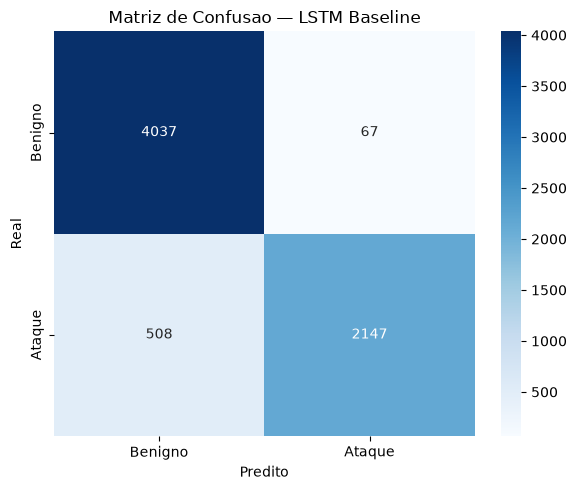

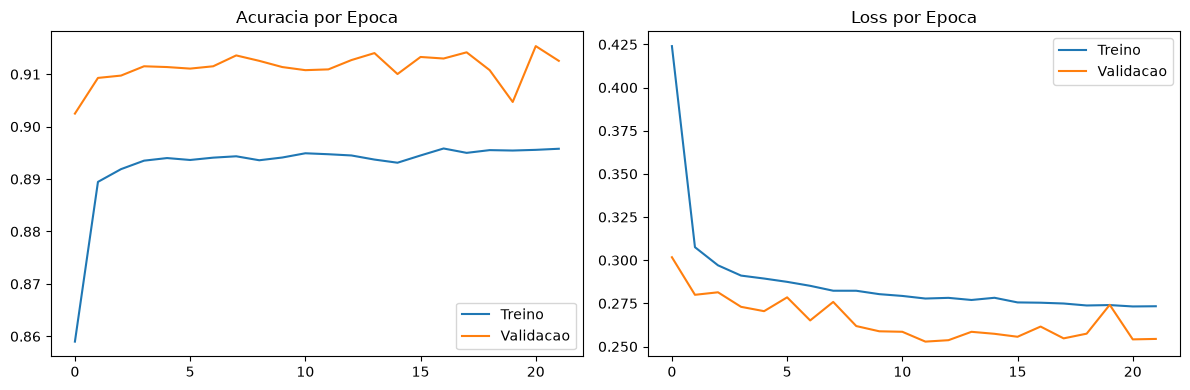

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicoes no conjunto de teste
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Relatorio completo
print("=== RELATORIO DE CLASSIFICACAO ===")
print(classification_report(y_test, y_pred, target_names=["Benigno", "Ataque"]))

# Matriz de confusao
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benigno", "Ataque"],
            yticklabels=["Benigno", "Ataque"])
plt.title("Matriz de Confusao — LSTM Baseline")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.tight_layout()
plt.savefig("../docs/matriz_confusao_baseline.png", dpi=150)
plt.show()

# Curvas de treino
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(history.history["accuracy"], label="Treino")
ax1.plot(history.history["val_accuracy"], label="Validacao")
ax1.set_title("Acuracia por Epoca")
ax1.legend()

ax2.plot(history.history["loss"], label="Treino")
ax2.plot(history.history["val_loss"], label="Validacao")
ax2.set_title("Loss por Epoca")
ax2.legend()

plt.tight_layout()
plt.savefig("../docs/curva_treino_baseline.png", dpi=150)
plt.show()